In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df=df[df['job_country']=='United States']

In [2]:
df['job_posted_month']=df['job_posted_date'].dt.month 
df_pivot_usa=df.pivot_table(
    index='job_posted_month',
    columns='job_title_short',
    aggfunc='size'
)

In [3]:
df_pivot_usa=df_pivot_usa.reset_index()

In [4]:
df_pivot_usa['job_posted_month']=pd.to_datetime(df_pivot_usa['job_posted_month'],format="%m").dt.month_name()

In [5]:
df_pivot_usa.set_index('job_posted_month',inplace=True)

In [6]:
temp=pd.read_csv("https://lukeb.co/software_csv")
temp

,job_posted_month,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
0,January,13619,9827,5108,4348
1,February,11456,9116,7298,4284
2,March,11102,8178,5814,4159
3,April,14037,9209,7232,4220
4,May,12126,8864,6718,4980
5,June,12003,8065,5902,4781
6,July,11914,8061,6839,4344
7,August,11571,8191,7413,4104
8,September,14016,8447,6139,4094
9,October,11419,8476,5026,4389


In [7]:
temp=temp.set_index('job_posted_month')
hold=df_pivot_usa.merge(temp,on='job_posted_month')
hold

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,13619,9827,5108,4348
February,447,24,6124,3060,4956,56,1258,878,1127,90,11456,9116,7298,4284
March,438,19,6218,3183,4779,59,1114,829,1150,115,11102,8178,5814,4159
April,565,40,6049,2801,4867,51,1025,781,991,112,14037,9209,7232,4220
May,279,20,4993,2976,4377,49,839,746,914,90,12126,8864,6718,4980
June,446,32,5683,2893,4645,48,1009,812,1033,93,12003,8065,5902,4781
July,581,39,5201,2570,4876,65,883,747,1095,153,11914,8061,6839,4344
August,903,39,6634,3269,6318,68,1186,903,1515,194,11571,8191,7413,4104
September,897,50,4639,3224,4568,113,805,775,1014,228,14016,8447,6139,4094


In [8]:
titles=df_pivot_usa.merge(temp,on='job_posted_month').sum().sort_values(ascending=False).head().index

In [9]:
hold=hold[titles]

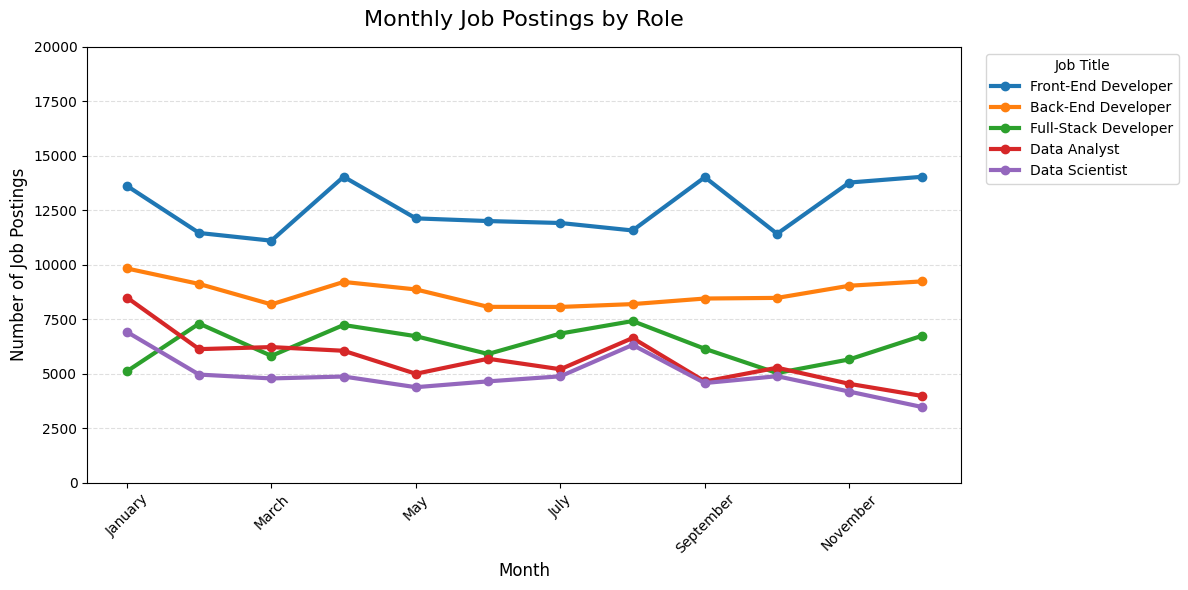

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

hold.plot(
    kind='line',
    linewidth=3,
    marker='o',
    ax=ax
)

ax.set_title(
    'Monthly Job Postings by Role',
    fontsize=16,
    pad=15
)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Job Postings', fontsize=12)

ax.set_ylim(0, 20000)

ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.legend(
    title='Job Title',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()